<a href="https://colab.research.google.com/github/diseasemodeling/MIE_525_625/blob/main/Lectures/4_MLP_heads/4a_CNN_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMage classfication: pretrained ResNet + MLP head--> classify digits
Dataset: MNIST  
ResNet: pretrained convolution network

In [ ]:
!pip install -q captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.6 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from captum.attr import FeatureAblation
from captum.attr import visualization as viz

In [ ]:
# -------------------------------------------------------------
# 1. DATASETS & LOADERS (Real MNIST via TorchVision)
# -------------------------------------------------------------
# Transform grayscale MNIST (1-channel) to 3-channels for ResNet compatibility
transform = transforms.Compose([
    transforms.Resize((224, 224)), # ResNet expects 224x224
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)), # 1 channel -> 3 channels
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Download full dataset but slice a small subset for quick student runtime
full_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
full_test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Subset to 128 training samples and 16 test samples for rapid demo
train_subset = Subset(full_train_dataset, range(128))
test_subset = Subset(full_test_dataset, range(16))

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=16, shuffle=False)

In [ ]:
# -------------------------------------------------------------
# 2. MODEL DEFINITIONS
# -------------------------------------------------------------
class ResNetWithMLP(nn.Module):
    """Full Model: ResNet18 + Custom MLP Classification Head."""
    def __init__(self, num_classes=10, hidden_dim=128, dropout_rate=0.3):
        super(ResNetWithMLP, self).__init__()
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        #FREEZE THE RESNET BASE HERE
        for param in self.resnet.parameters():
            param.requires_grad = False

        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity() # Strip original output layer

        # Deep MLP Head
        self.mlp_head = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.mlp_head(self.resnet(x))

class AblatedResNet(nn.Module): # was the deeper MLP head needed - ablates it to check
    """Ablated Model: Deeper MLP components removed (Direct Linear Probe)."""
    def __init__(self, num_classes=10):
        super(AblatedResNet, self).__init__()
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.resnet.fc.in_features
        # Ablation step: Swap hidden layers out for an immediate linear classifier
        self.resnet.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.resnet(x)


In [ ]:
# -------------------------------------------------------------
# 3. RUNTIME TRAINING LOOP
# -------------------------------------------------------------
def train_model(model, loader, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3) # if finetuning, i.e., no freeze on basemodel, keep this small, so the full network doesnt get overwritten
    model.train()

    for epoch in range(epochs):
        for images, labels in loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

def evaluate_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return (correct / total) * 100

# Run experiments
print("⏳ Training Full Model (ResNet + MLP)...")
full_model = ResNetWithMLP()
train_model(full_model, train_loader)
full_acc = evaluate_accuracy(full_model, test_loader)

print("⏳ Training Ablated Model (Direct Linear)...")
ablated_model = AblatedResNet()
train_model(ablated_model, train_loader)
ablated_acc = evaluate_accuracy(ablated_model, test_loader)

⏳ Training Full Model (ResNet + MLP)...
⏳ Training Ablated Model (Direct Linear)...


In [ ]:
#print(full_model)

In [ ]:
# -------------------------------------------------------------
# 4. VISUALIZATION A: VISUALIZE CLASSIFICATIONS
# -------------------------------------------------------------
def visualize_predictions(model, loader, num_images=5):
    model.eval()
    images, labels = next(iter(loader))

    with torch.no_grad():
        outputs = model(images)
        _, preds = outputs.max(1)

    plt.figure(figsize=(12, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)

        # Undo normalization to map tensor to visual channels
        img = images[i].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        # Display configuration
        plt.imshow(img)
        color = 'green' if preds[i] == labels[i] else 'red'
        plt.title(f"True: {labels[i].item()}\nPred: {preds[i].item()}", color=color)
        plt.axis('off')
    plt.suptitle("Real-time Model Inference Samples", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()



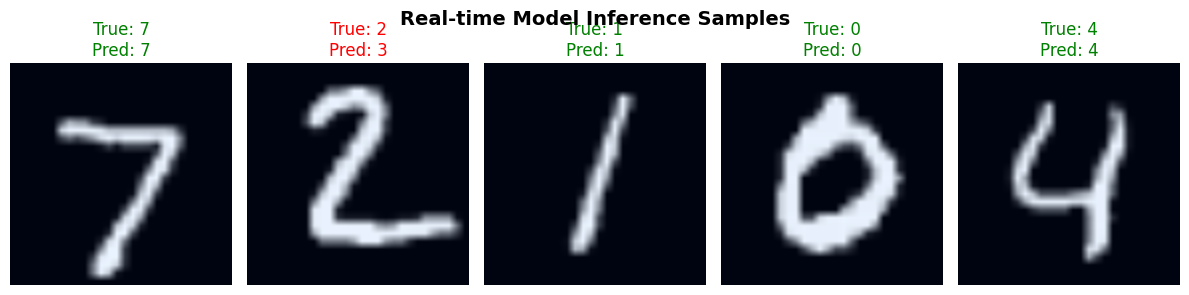

In [ ]:
# Trigger our visual check
# -------------------------------------------------------------
# VIEEW FULL MODEL (with MLP HEAD)
# -------------------------------------------------------------
visualize_predictions(full_model, test_loader)

# MODEL ABLATION

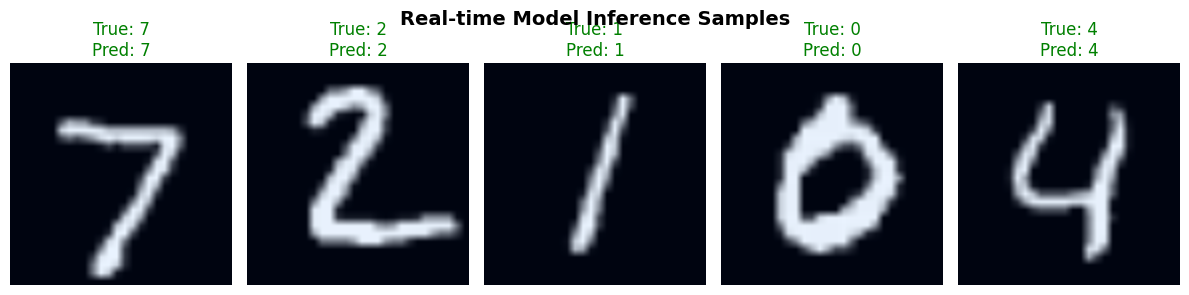

In [ ]:
# -------------------------------------------------------------
# VIEEW ABLATED MODEL (no MLP HEAD - direct ResNet)
# -------------------------------------------------------------
visualize_predictions(ablated_model, test_loader)

# Feature Ablation
feature => pixel here; darker the color of a pixel lower its importance

In [ ]:
# -------------------------------------------------------------
# 4. FEATURE ABLATION FOR AN MNIST DIGIT (MODIFIED FOR 224x224x3)
# -------------------------------------------------------------
print("🔍 Extracting a test sample for feature ablation...")

# Extract exactly one batch from your test loader
images, labels = next(iter(test_loader))
single_image = images[0:1]  # Shape is now [1, 3, 224, 224]
true_label = true_label = labels[0].item()

# 1. Run inference to see what the trained model predicts
full_model.eval()
with torch.no_grad():
    output = full_model(single_image)
    probabilities = torch.nn.functional.softmax(output, dim=1)
    confidence, predicted_idx = torch.max(probabilities, 1)
    predicted_idx = predicted_idx.item()

print(f"Target Label: {true_label} | Model Predicted: {predicted_idx} ({confidence.item()*100:.2f}% Confidence)")

# 2. FIXED: Define a feature mask that matches the 224x224 size
# We use 8x8 pixel blocks to ablate the image so it evaluates fast.
# 224 / 8 = 28 blocks across the width and height.
mask_grid = torch.arange(0, 28 * 28).view(28, 28)
mask_grid = mask_grid.repeat_interleave(8, dim=0).repeat_interleave(8, dim=1)  # Stretch to 224x224

# Duplicate the mask grid identically across all 3 color channels
feature_mask = mask_grid.unsqueeze(0).repeat(3, 1, 1).unsqueeze(0)  # Shape: [1, 3, 224, 224]

# 3. Compute feature ablation attributions targeting the predicted class
ablator = FeatureAblation(full_model)
attributions = ablator.attribute(
    single_image,
    target=predicted_idx,
    feature_mask=feature_mask.to(images.device)
)

# 4. FIXED: Un-normalize the ImageNet transforms so the final plot isn't distorted
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
unnormalized_image = (single_image.squeeze(0).cpu() * std) + mean
unnormalized_image = torch.clamp(unnormalized_image, 0, 1)  # Keep pixel boundaries valid [0, 1]

# Format tensors into standard Numpy image matrix layouts (H, W, C)
img_np = unnormalized_image.permute(1, 2, 0).numpy()
attr_np = attributions.squeeze(0).permute(1, 2, 0).cpu().numpy()



🔍 Extracting a test sample for feature ablation...
Target Label: 7 | Model Predicted: 7 (35.86% Confidence)


## Feature ablation: feature => pixel here; darker the color of a pixel lower its importance in influencing the classification

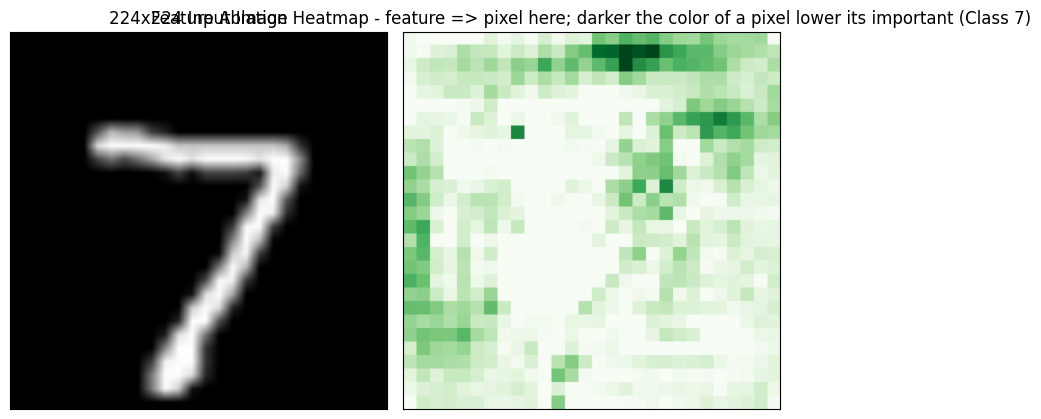

In [ ]:
# 5. Generate and show the Feature Importance Heatmap
fig, axis = viz.visualize_image_attr_multiple(
    attr=attr_np,
    original_image=img_np,
    methods=["original_image", "heat_map"],
    signs=["all", "positive"],
    titles=["224x224 Input Image", f"Feature Ablation Heatmap  (Class {predicted_idx})"]
)
plt.show()
